# Histogram

A histogram sorts the values of one numeric variable into bins and counts them, so it answers *what shape does this distribution have*: where the values pile up, how widely they spread, whether they lean to one side, have two peaks, or trail off into outliers. This guide shows how to create histograms with the [datachart.charts.Histogram](../../../references/charts/histogram/#datachart.charts.Histogram) function, starting with the basics and building up to worked examples on real data.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-histogram), which maps common tasks to the parameter or style attribute that does the job.

In [1]:
from datachart.charts import Histogram

## Basics

The examples in this guide share one dataset: the flipper length, in millimeters, of the 342 penguins measured on three islands of the Palmer Archipelago, Antarctica (source: the [Palmer penguins](https://allisonhorst.github.io/palmerpenguins/) dataset, Gorman, Williams and Fraser 2014, released under CC0). The data lives in a hidden cell. `penguins` holds one data point per penguin, and `penguins_by_species` holds one list per species (Adelie, Chinstrap and Gentoo, in the order of `SPECIES`). The pooled flipper lengths hide a story: they come from three species of different build, and the histogram shows it as two peaks that the customizations below bring out.

In [2]:
SPECIES = ["Adelie", "Chinstrap", "Gentoo"]

# Palmer penguins (Gorman et al. 2014, CC0): (flipper length in mm, body mass in g) per penguin
PENGUINS = {
    "Adelie": [
        (181, 3750), (186, 3800), (195, 3250), (193, 3450), (190, 3650), (181, 3625),
        (195, 4675), (193, 3475), (190, 4250), (186, 3300), (180, 3700), (182, 3200),
        (191, 3800), (198, 4400), (185, 3700), (195, 3450), (197, 4500), (184, 3325),
        (194, 4200), (174, 3400), (180, 3600), (189, 3800), (185, 3950), (180, 3800),
        (187, 3800), (183, 3550), (187, 3200), (172, 3150), (180, 3950), (178, 3250),
        (178, 3900), (188, 3300), (184, 3900), (195, 3325), (196, 4150), (190, 3950),
        (180, 3550), (181, 3300), (184, 4650), (182, 3150), (195, 3900), (186, 3100),
        (196, 4400), (185, 3000), (190, 4600), (182, 3425), (179, 2975), (190, 3450),
        (191, 4150), (186, 3500), (188, 4300), (190, 3450), (200, 4050), (187, 2900),
        (191, 3700), (186, 3550), (193, 3800), (181, 2850), (194, 3750), (185, 3150),
        (195, 4400), (185, 3600), (192, 4050), (184, 2850), (192, 3950), (195, 3350),
        (188, 4100), (190, 3050), (198, 4450), (190, 3600), (190, 3900), (196, 3550),
        (197, 4150), (190, 3700), (195, 4250), (191, 3700), (184, 3900), (187, 3550),
        (195, 4000), (189, 3200), (196, 4700), (187, 3800), (193, 4200), (191, 3350),
        (194, 3550), (190, 3800), (189, 3500), (189, 3950), (190, 3600), (202, 3550),
        (205, 4300), (185, 3400), (186, 4450), (187, 3300), (208, 4300), (190, 3700),
        (196, 4350), (178, 2900), (192, 4100), (192, 3725), (203, 4725), (183, 3075),
        (190, 4250), (193, 2925), (184, 3550), (199, 3750), (190, 3900), (181, 3175),
        (197, 4775), (198, 3825), (191, 4600), (193, 3200), (197, 4275), (191, 3900),
        (196, 4075), (188, 2900), (199, 3775), (189, 3350), (189, 3325), (187, 3150),
        (198, 3500), (176, 3450), (202, 3875), (186, 3050), (199, 4000), (191, 3275),
        (195, 4300), (191, 3050), (210, 4000), (190, 3325), (197, 3500), (193, 3500),
        (199, 4475), (187, 3425), (190, 3900), (191, 3175), (200, 3975), (185, 3400),
        (193, 4250), (193, 3400), (187, 3475), (188, 3050), (190, 3725), (192, 3000),
        (185, 3650), (190, 4250), (184, 3475), (195, 3450), (193, 3750), (187, 3700),
        (201, 4000),
    ],
    "Chinstrap": [
        (192, 3500), (196, 3900), (193, 3650), (188, 3525), (197, 3725), (198, 3950),
        (178, 3250), (197, 3750), (195, 4150), (198, 3700), (193, 3800), (194, 3775),
        (185, 3700), (201, 4050), (190, 3575), (201, 4050), (197, 3300), (181, 3700),
        (190, 3450), (195, 4400), (181, 3600), (191, 3400), (187, 2900), (193, 3800),
        (195, 3300), (197, 4150), (200, 3400), (200, 3800), (191, 3700), (205, 4550),
        (187, 3200), (201, 4300), (187, 3350), (203, 4100), (195, 3600), (199, 3900),
        (195, 3850), (210, 4800), (192, 2700), (205, 4500), (210, 3950), (187, 3650),
        (196, 3550), (196, 3500), (196, 3675), (201, 4450), (190, 3400), (212, 4300),
        (187, 3250), (198, 3675), (199, 3325), (201, 3950), (193, 3600), (203, 4050),
        (187, 3350), (197, 3450), (191, 3250), (203, 4050), (202, 3800), (194, 3525),
        (206, 3950), (189, 3650), (195, 3650), (207, 4000), (202, 3400), (193, 3775),
        (210, 4100), (198, 3775),
    ],
    "Gentoo": [
        (211, 4500), (230, 5700), (210, 4450), (218, 5700), (215, 5400), (210, 4550),
        (211, 4800), (219, 5200), (209, 4400), (215, 5150), (214, 4650), (216, 5550),
        (214, 4650), (213, 5850), (210, 4200), (217, 5850), (210, 4150), (221, 6300),
        (209, 4800), (222, 5350), (218, 5700), (215, 5000), (213, 4400), (215, 5050),
        (215, 5000), (215, 5100), (216, 4100), (215, 5650), (210, 4600), (220, 5550),
        (222, 5250), (209, 4700), (207, 5050), (230, 6050), (220, 5150), (220, 5400),
        (213, 4950), (219, 5250), (208, 4350), (208, 5350), (208, 3950), (225, 5700),
        (210, 4300), (216, 4750), (222, 5550), (217, 4900), (210, 4200), (225, 5400),
        (213, 5100), (215, 5300), (210, 4850), (220, 5300), (210, 4400), (225, 5000),
        (217, 4900), (220, 5050), (208, 4300), (220, 5000), (208, 4450), (224, 5550),
        (208, 4200), (221, 5300), (214, 4400), (231, 5650), (219, 4700), (230, 5700),
        (214, 4650), (229, 5800), (220, 4700), (223, 5550), (216, 4750), (221, 5000),
        (221, 5100), (217, 5200), (216, 4700), (230, 5800), (209, 4600), (220, 6000),
        (215, 4750), (223, 5950), (212, 4625), (221, 5450), (212, 4725), (224, 5350),
        (212, 4750), (228, 5600), (218, 4600), (218, 5300), (212, 4875), (230, 5550),
        (218, 4950), (228, 5400), (212, 4750), (224, 5650), (214, 4850), (226, 5200),
        (216, 4925), (222, 4875), (203, 4625), (225, 5250), (219, 4850), (228, 5600),
        (215, 4975), (228, 5500), (216, 4725), (215, 5500), (210, 4700), (219, 5500),
        (208, 4575), (209, 5500), (216, 5000), (229, 5950), (213, 4650), (230, 5500),
        (217, 4375), (230, 5850), (217, 4875), (222, 6000), (214, 4925), (215, 4850),
        (222, 5750), (212, 5200), (213, 5400),
    ],
}

penguins = [
    {"x": flipper, "species": species, "body_mass": mass}
    for species in SPECIES
    for flipper, mass in PENGUINS[species]
]
penguins_by_species = [
    [point for point in penguins if point["species"] == species]
    for species in SPECIES
]
FLIPPER_TICKS = [170, 180, 190, 200, 210, 220, 230]

Each data point is a dictionary with an `x` value, here the flipper length, which the histogram bins and counts. Other keys, such as the species, are carried along and ignored:

In [3]:
penguins[:3]

[{'x': 181, 'species': 'Adelie', 'body_mass': 3750},
 {'x': 186, 'species': 'Adelie', 'body_mass': 3800},
 {'x': 195, 'species': 'Adelie', 'body_mass': 3250}]

**Basic example.** Only the `data` argument is required. The values are split into 20 equal-width bins by default, and the two peaks are already visible:

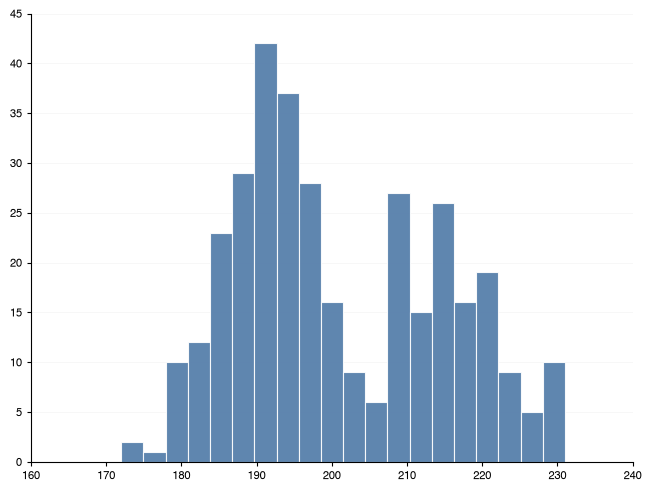

In [4]:
Histogram(
    # add the data to the chart
    data=penguins
).show()

## Customizing the Histogram

Every customization is either a keyword argument of `Histogram` or a `plot_hist_*` attribute of its `style` dictionary. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                   | Use                                                              | See |
| :------------------------------------------- | :--------------------------------------------------------------- | :-- |
| add a title and axis labels                  | `title`, `xlabel`, `ylabel`                                      | [Title, axis labels and ticks](#title-axis-labels-and-ticks) |
| set tick positions, labels, and rotation     | `xticks`, `xticklabels`, `xtickrotate` (and the `y` versions)     | [Title, axis labels and ticks](#title-axis-labels-and-ticks) |
| fix the axis range                           | `xmin`, `xmax`, `ymin`, `ymax`                                   | [Title, axis labels and ticks](#title-axis-labels-and-ticks) |
| resize the figure                            | `figsize`                                                        | [Figure size and grid](#figure-size-and-grid) |
| show grid lines                              | `show_grid`                                                      | [Figure size and grid](#figure-size-and-grid) |
| fix the aspect ratio of the axes             | `aspect_ratio`                                                   | [Figure size and grid](#figure-size-and-grid) |
| change how finely the values are binned      | `num_bins`                                                       | [Number of bins](#number-of-bins) |
| draw the bins as bars or a step outline      | `style={"plot_hist_type": ...}`                                  | [Histogram style](#histogram-style) |
| change the color, hatch, or edge of the bins | `style={"plot_hist_color": ..., "plot_hist_hatch": ...}`         | [Histogram style](#histogram-style) |
| draw the bars horizontally                   | `orientation`                                                    | [Orientation](#orientation) |
| print the count at the top of each bin       | `show_values`, `value_format`                                    | [Value labels](#value-labels) |
| mark a mean, a median, or a cut-off          | `vlines`, `hlines`                                               | [Reference lines and bands](#reference-lines-and-bands) |
| shade a range of values                      | `vspans`, `hspans`                                               | [Reference lines and bands](#reference-lines-and-bands) |
| put a note on the chart                      | `texts`                                                          | [Text annotations](#text-annotations) |
| compare several distributions in one chart   | `data` as a list of lists, `subtitle`, `style`, `show_legend`    | [Multiple Histograms](#multiple-histograms) |
| stack or overlay the series                  | `bar_mode`                                                       | [Bar mode](#bar-mode) |
| highlight one series, mute the rest          | `emphasis`, `emphasis_rule`                                      | [Emphasis](#emphasis) |
| title and place the legend                   | `legend`                                                         | [Legend](#legend) |
| draw each series in its own subplot          | `subplots`, `sharex`, `sharey`, `max_cols`                       | [Subplots](#subplots) |
| compare samples of different sizes           | `show_density`                                                   | [Density view](#density-view) |
| overlay a smooth density curve               | `stats.kde1d`, `LineChart`, `Panel`                              | [Density curve](#density-curve) |
| read off how many values fall below a value  | `show_cumulative`                                                | [Cumulative view](#cumulative-view) |
| use a logarithmic axis                       | `scaley`, `scalex`                                               | [Axis scales](#axis-scales) |
| plot data with other key names               | `x`                                                              | [Custom data keys](#custom-data-keys) |
| save the chart to a file                     | `save_figure`                                                    | [Saving Figures](../../utility/saving/) guide |

The parameters that accept a constant, with the class in [datachart.constants](../../../references/constants/) that lists its values:

| Parameter | Constant |
| :-- | :-- |
| `style={"plot_hist_type": ...}` | [`HISTOGRAM_TYPE`](../../../references/constants/#datachart.constants.HISTOGRAM_TYPE) |
| `emphasis` | [`EMPHASIS`](../../../references/constants/#datachart.constants.EMPHASIS) |
| `figsize` | [`FIG_SIZE`](../../../references/constants/#datachart.constants.FIG_SIZE) |
| `legend={"location": ..., "alignment": ...}` | [`LEGEND_LOCATION`](../../../references/constants/#datachart.constants.LEGEND_LOCATION), [`LEGEND_ALIGN`](../../../references/constants/#datachart.constants.LEGEND_ALIGN) |
| `show_grid` | [`SHOW_GRID`](../../../references/constants/#datachart.constants.SHOW_GRID) |
| `value_format` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT) |
| `aspect_ratio` | [`ASPECT_RATIO`](../../../references/constants/#datachart.constants.ASPECT_RATIO) |
| `orientation` | [`ORIENTATION`](../../../references/constants/#datachart.constants.ORIENTATION) |
| `bar_mode` | [`BAR_MODE`](../../../references/constants/#datachart.constants.BAR_MODE) |
| `scalex` | [`SCALE`](../../../references/constants/#datachart.constants.SCALE) |
| `scaley` | [`SCALE`](../../../references/constants/#datachart.constants.SCALE) |

The full list of style attributes is in the [datachart.typings.HistStyleAttrs](../../../references/charts/histogram/#datachart.typings.HistStyleAttrs) type; the full list of parameters is in the [datachart.charts.Histogram](../../../references/charts/histogram/#datachart.charts.Histogram) reference.

### Title, axis labels and ticks

Without a title and axis labels the reader cannot tell what was measured or what the bars count; `title`, `xlabel` and `ylabel` say it. The automatic ticks rarely land on values people think in, so `xticks` places them every 10 mm (`xticklabels` would rename them, and `xtickrotate` would tilt them). `xmin` and `xmax` fix the range of the binned axis, which keeps several charts of the same variable aligned.

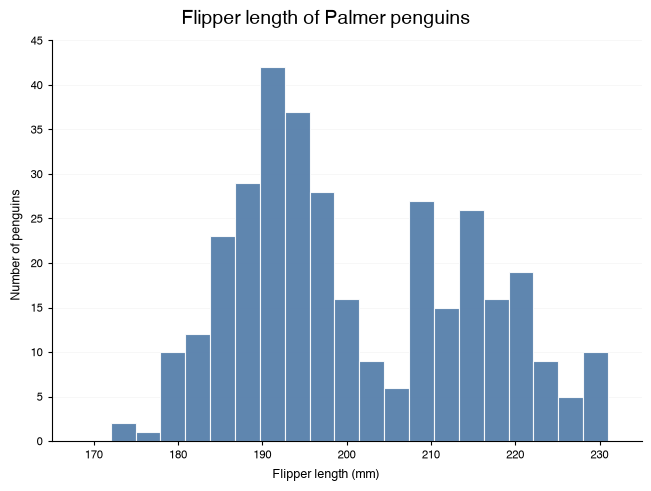

In [5]:
Histogram(
    data=penguins,
    # add the title
    title="Flipper length of Palmer penguins",
    # add the x and y axis labels
    xlabel="Flipper length (mm)",
    ylabel="Number of penguins",
    # tick the flipper length every 10 mm
    xticks=FLIPPER_TICKS,
    # fix the range of the binned axis
    xmin=165,
    xmax=235,
).show()

### Figure size and grid

A distribution is wider than it is tall, so a wide, short figure suits it. `figsize` takes a `(width, height)` tuple in inches or one of the presets in [FIG_SIZE](../../../references/constants/#datachart.constants.FIG_SIZE), sized for a full or half page width.

The counts are read off the y-axis, so [SHOW_GRID.Y](../../../references/constants/#datachart.constants.SHOW_GRID) is the grid a vertical histogram needs; `SHOW_GRID.X` and `SHOW_GRID.BOTH` are the other options. `aspect_ratio` ([ASPECT_RATIO](../../../references/constants/#datachart.constants.ASPECT_RATIO)) fixes the ratio of the axes rather than of the figure; a histogram has counts on one axis and values on the other, so the examples leave it at the default.

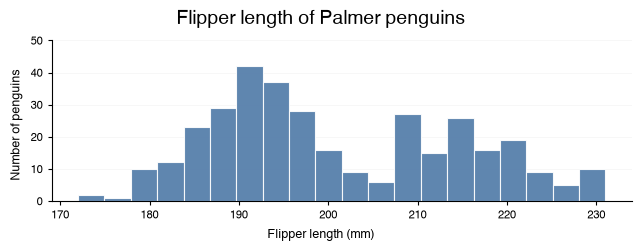

In [6]:
from datachart.constants import FIG_SIZE, SHOW_GRID

Histogram(
    data=penguins,
    title="Flipper length of Palmer penguins",
    xlabel="Flipper length (mm)",
    ylabel="Number of penguins",
    xticks=FLIPPER_TICKS,
    # a wide, short figure
    figsize=FIG_SIZE.FULL_SHORT,
    # grid lines along the count axis only
    show_grid=SHOW_GRID.Y,
).show()

### Number of bins

The bin count decides which story the histogram tells, so it is worth choosing on purpose. `num_bins` sets it (20 by default). The flipper lengths span 172 to 231 mm. With 4 bins, each about 15 mm wide, the two peaks merge into one, and the distribution looks like a single peak with a long right tail. With 20 bins the dip between the peaks shows. With 120 bins each bin is half a millimeter wide, narrower than the whole millimeters the lengths were recorded in, so every other bin is empty and the chart is mostly noise.

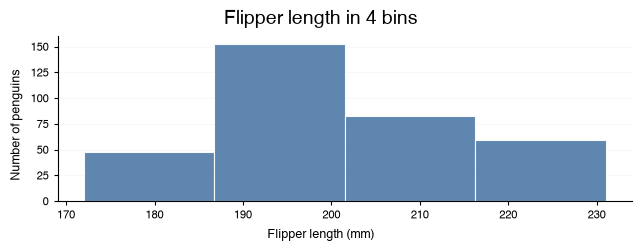

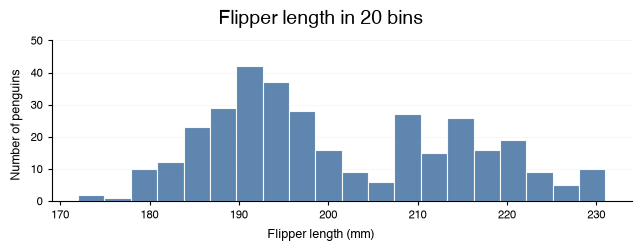

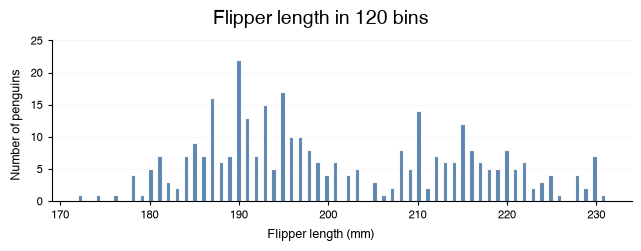

In [7]:
for num_bins in [4, 20, 120]:
    Histogram(
        data=penguins,
        title=f"Flipper length in {num_bins} bins",
        xlabel="Flipper length (mm)",
        ylabel="Number of penguins",
        xticks=FLIPPER_TICKS,
        figsize=FIG_SIZE.FULL_SHORT,
        show_grid=SHOW_GRID.Y,
        # the number of equal-width bins
        num_bins=num_bins,
    ).show()

### Histogram style

The `style` dictionary sets the look of the bins; the attributes are listed in [datachart.typings.HistStyleAttrs](../../../references/charts/histogram/#datachart.typings.HistStyleAttrs), and any attribute left out keeps the value of the active theme. `plot_hist_type` takes a [HISTOGRAM_TYPE](../../../references/constants/#datachart.constants.HISTOGRAM_TYPE): `BAR` draws one bar per bin (the default), `STEP` an unfilled outline, and `STEP_FILLED` a filled outline with no lines between the bins, which reads as one shape rather than a row of bars. For `STEP` the outline is the mark itself and takes the series color; `plot_hist_edge_color` and `plot_hist_edge_width` override it. A hatch from [HATCH_STYLE](../../../references/constants/#datachart.constants.HATCH_STYLE) and a dark edge keep the shape readable when printed in greyscale.

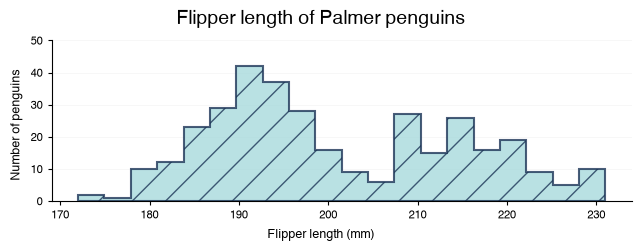

In [8]:
from datachart.constants import HATCH_STYLE, HISTOGRAM_TYPE

Histogram(
    data=penguins,
    # one filled shape with a hatch and a dark outline
    style={
        "plot_hist_type": HISTOGRAM_TYPE.STEP_FILLED,
        "plot_hist_color": "#a8dadc",
        "plot_hist_alpha": 0.8,
        "plot_hist_hatch": HATCH_STYLE.DIAGONAL,
        "plot_hist_edge_width": 1.5,
        "plot_hist_edge_color": "#1d3557",
    },
    title="Flipper length of Palmer penguins",
    xlabel="Flipper length (mm)",
    ylabel="Number of penguins",
    xticks=FLIPPER_TICKS,
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

### Orientation

A horizontal histogram puts the values on the y-axis, which suits a variable people read top to bottom (depth, altitude, age) or a histogram placed beside another chart that shares that axis. `orientation=ORIENTATION.HORIZONTAL` ([ORIENTATION](../../../references/constants/#datachart.constants.ORIENTATION)) draws the bars from the y-axis; the axis labels, the ticks and the grid swap with it.

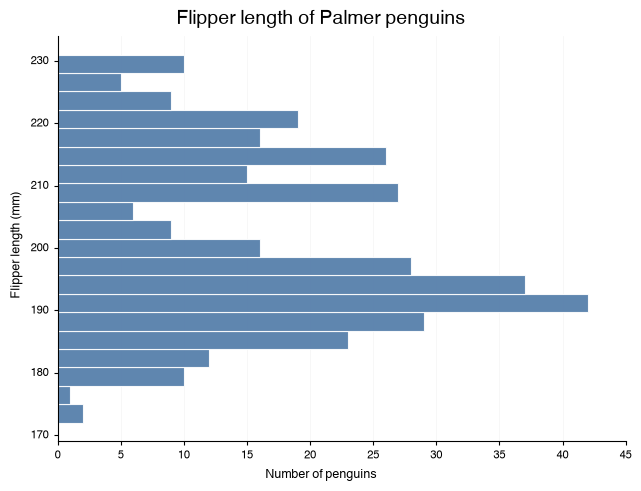

In [9]:
from datachart.constants import ORIENTATION

Histogram(
    data=penguins,
    title="Flipper length of Palmer penguins",
    # the axis labels swap with the orientation
    xlabel="Number of penguins",
    ylabel="Flipper length (mm)",
    yticks=FLIPPER_TICKS,
    figsize=FIG_SIZE.FULL_MEDIUM,
    # and so does the grid
    show_grid=SHOW_GRID.X,
    # draw the bars from the y-axis
    orientation=ORIENTATION.HORIZONTAL,
).show()

### Value labels

When the reader needs the exact counts, say to check how many penguins fall in the dip between the peaks, `show_values` prints each bin's count at its top, and `value_format` formats it: a [VALUE_FORMAT](../../../references/constants/#datachart.constants.VALUE_FORMAT) constant or any `"{x:.1f}"`, `"{:.1f}%"` or `"%g"` style string. Empty bins stay bare. Labels need room, so the example uses fewer bins and extends the count axis a little.

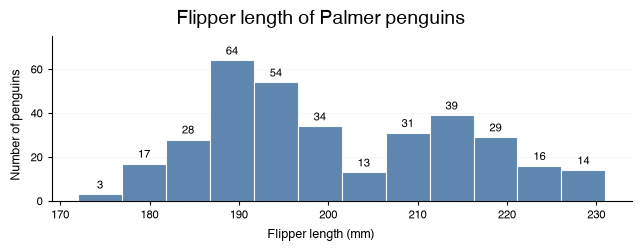

In [10]:
from datachart.constants import VALUE_FORMAT

Histogram(
    data=penguins,
    title="Flipper length of Palmer penguins",
    xlabel="Flipper length (mm)",
    ylabel="Number of penguins",
    xticks=FLIPPER_TICKS,
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    num_bins=12,
    ymax=75,
    # print the count of every bin
    show_values=True,
    value_format=VALUE_FORMAT.INTEGER,
).show()

### Reference lines and bands

A summary statistic means more when it sits on the distribution it summarizes. `vlines` draws a vertical line at a value of the binned variable (a mean, a median, a cut-off) and `hlines` a horizontal one at a count. `vspans` and `hspans` shade a range instead. Each takes a dictionary or a list of them, with the position, an optional `label` for the legend, and a `style`; the keys are listed in [VLineSettingAttrs](../../../references/typings/#datachart.typings.VLineSettingAttrs), [HLineSettingAttrs](../../../references/typings/#datachart.typings.HLineSettingAttrs), [VSpanSettingAttrs](../../../references/typings/#datachart.typings.VSpanSettingAttrs) and [HSpanSettingAttrs](../../../references/typings/#datachart.typings.HSpanSettingAttrs).

The example marks the mean (201 mm) and the median (197 mm) and shades one standard deviation around the mean. The mean sits right of the median because the long-flippered Gentoo penguins pull it, and it lands on the slope down into the dip between the peaks: for a two-peaked distribution the "typical" value describes few of the penguins. The taller figure and `ymax` leave the legend room above the bars.

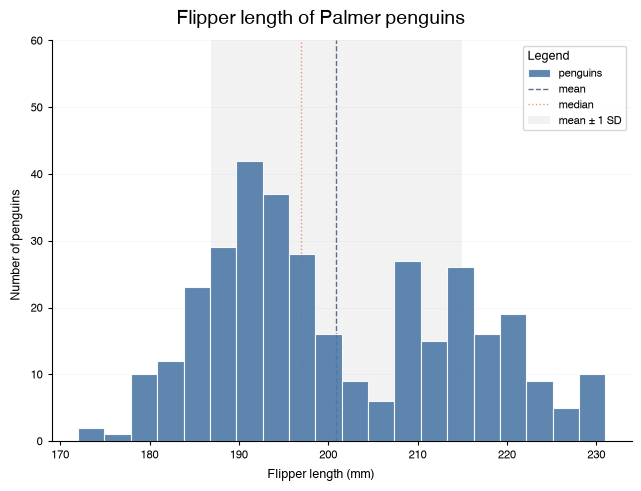

In [11]:
from datachart.constants import LINE_STYLE

flippers = [point["x"] for point in penguins]
mean_flipper = sum(flippers) / len(flippers)
median_flipper = sorted(flippers)[len(flippers) // 2]
std_flipper = (sum((f - mean_flipper) ** 2 for f in flippers) / len(flippers)) ** 0.5

Histogram(
    data=penguins,
    subtitle="penguins",
    # the mean and the median as lines
    vlines=[
        {
            "x": mean_flipper,
            "label": "mean",
            "style": {"plot_vline_color": "#1d3557", "plot_vline_style": LINE_STYLE.DASHED},
        },
        {
            "x": median_flipper,
            "label": "median",
            "style": {"plot_vline_color": "#e76f51", "plot_vline_style": LINE_STYLE.DOTTED},
        },
    ],
    # one standard deviation around the mean as a band
    vspans={
        "xmin": mean_flipper - std_flipper,
        "xmax": mean_flipper + std_flipper,
        "label": "mean ± 1 SD",
    },
    title="Flipper length of Palmer penguins",
    xlabel="Flipper length (mm)",
    ylabel="Number of penguins",
    xticks=FLIPPER_TICKS,
    figsize=FIG_SIZE.FULL_MEDIUM,
    ymax=60,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
).show()

### Text annotations

A peak that has an explanation deserves one. `texts` places text on the chart, with an optional `target` to draw a connector to a point; the position is in data coordinates by default (value, count) or in axes fractions with `"coords": "axes"`. The keys are listed in [TextSettingAttrs](../../../references/typings/#datachart.typings.TextSettingAttrs), and the [Text Annotations](../../utility/annotations/) guide covers placement and styling. The notes below name the species behind each peak.

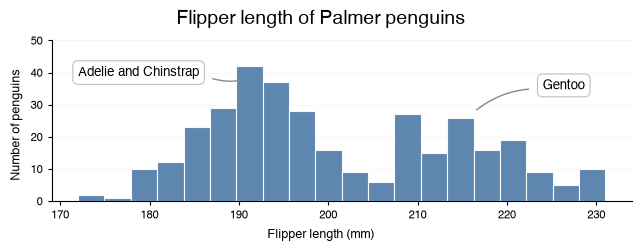

In [12]:
Histogram(
    data=penguins,
    # one note per peak, each pointing at the top of its peak
    texts=[
        {"text": "Adelie and Chinstrap", "x": 172, "y": 40, "target": (191, 38)},
        {"text": "Gentoo", "x": 224, "y": 36, "target": (216, 27)},
    ],
    title="Flipper length of Palmer penguins",
    xlabel="Flipper length (mm)",
    ylabel="Number of penguins",
    xticks=FLIPPER_TICKS,
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    ymax=50,
).show()

## Multiple Histograms

To compare distributions, pass a list of lists to `data`: each inner list is one series, and the per-series attributes (`subtitle`, `style`, `emphasis`, `x`) become lists aligned with it. A single `style` dictionary applies to every series, while a list styles each one (`None` keeps the theme style). `penguins_by_species` is such a list, and splitting the pooled data by species explains the two peaks. By default the series share one set of bins and are **stacked**, so the outline of the stack is the pooled histogram from the Basics section and the colors show which species fills each bin: the Adelie and Chinstrap penguins make the left peak, the Gentoo penguins the right one.

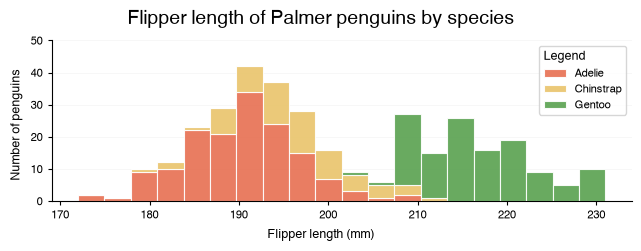

In [13]:
Histogram(
    # one series per species
    data=penguins_by_species,
    # named for the legend
    subtitle=SPECIES,
    # one style per series; None keeps the theme color
    style=[{"plot_hist_color": "#e76f51"}, {"plot_hist_color": "#e9c46a"}, None],
    title="Flipper length of Palmer penguins by species",
    xlabel="Flipper length (mm)",
    ylabel="Number of penguins",
    xticks=FLIPPER_TICKS,
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
).show()

### Bar mode

A stack answers *what makes up each bin*, but hides the shape of every series except the bottom one. `bar_mode` ([BAR_MODE](../../../references/constants/#datachart.constants.BAR_MODE)) changes that: `BAR_MODE.OVERLAY` draws every series from zero on the shared bins, one over the other, so each species shows its own shape and the overlap between Adelie and Chinstrap becomes visible. `BAR_MODE.STACK` is the default, and `BAR_MODE.GROUP` behaves like overlay. A step outline keeps the overlaid series from hiding each other.

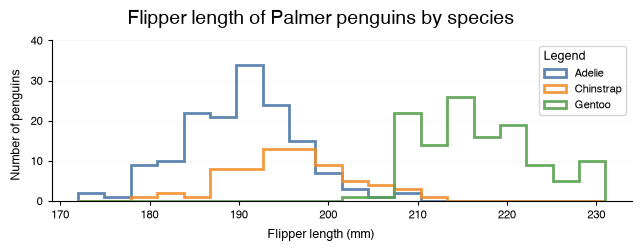

In [14]:
from datachart.constants import BAR_MODE

Histogram(
    data=penguins_by_species,
    subtitle=SPECIES,
    # outlines, so no series hides another
    style={"plot_hist_type": HISTOGRAM_TYPE.STEP, "plot_hist_edge_width": 2},
    title="Flipper length of Palmer penguins by species",
    xlabel="Flipper length (mm)",
    ylabel="Number of penguins",
    xticks=FLIPPER_TICKS,
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
    # every series from zero, on the shared bins
    bar_mode=BAR_MODE.OVERLAY,
).show()

### Emphasis

When the question is about one of the series, `emphasis` takes one role per series, aligned with `data`: `"highlight"` bolds a series and brings it to the front, `"background"` mutes it and drops it from the legend, `None` leaves it as it is ([EMPHASIS](../../../references/constants/#datachart.constants.EMPHASIS)). As soon as any series carries a role, the histograms are overlaid rather than stacked, since a muted series stacked under a highlighted one would lift it off the axis. Asking *how do the Gentoo penguins differ* turns the other two species into context. The [Highlighting](../../styling/highlighting/) guide covers emphasis across every chart type and theme.

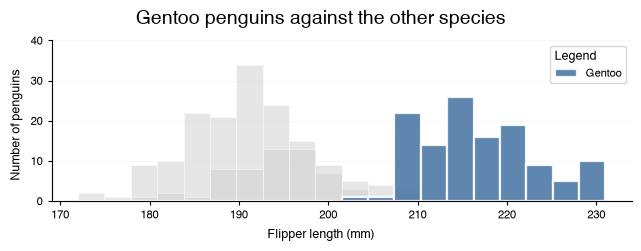

In [15]:
Histogram(
    data=penguins_by_species,
    subtitle=SPECIES,
    # the Gentoo penguins are the question, the rest the context
    emphasis=["background", "background", "highlight"],
    title="Gentoo penguins against the other species",
    xlabel="Flipper length (mm)",
    ylabel="Number of penguins",
    xticks=FLIPPER_TICKS,
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
).show()

`emphasis_rule` picks the series from the data instead. It is a one-key rule, `{"top": n}` or `{"bottom": n}` by rank, `{"above": v}` or `{"below": v}` (strict), or `{"between": (lo, hi)}` (inclusive), read against a summary of each series' own values: the mean by default, or the `"median"`, `"min"`, `"max"` or `"sum"` named by a `"by"` key. An explicit `emphasis` role wins over the rule. The rule below highlights the species whose median flipper is shortest:

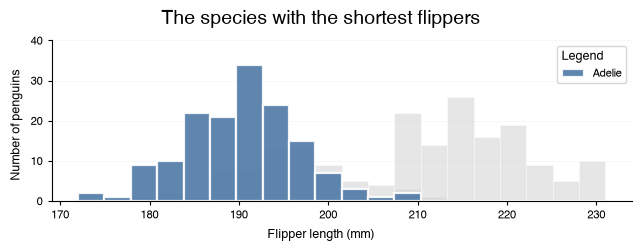

In [16]:
Histogram(
    data=penguins_by_species,
    subtitle=SPECIES,
    # the series with the smallest median
    emphasis_rule={"bottom": 1, "by": "median"},
    title="The species with the shortest flippers",
    xlabel="Flipper length (mm)",
    ylabel="Number of penguins",
    xticks=FLIPPER_TICKS,
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
).show()

### Legend

`show_legend` lists the series; `legend` says where and how, with a `title`, a `location` from [LEGEND_LOCATION](../../../references/constants/#datachart.constants.LEGEND_LOCATION), the number of columns `ncols`, and the `alignment` of the entries from [LEGEND_ALIGN](../../../references/constants/#datachart.constants.LEGEND_ALIGN); a field left out falls back to the theme ([LegendSettingAttrs](../../../references/typings/#datachart.typings.LegendSettingAttrs)). The two peaks leave little room at the top of the axes, so the legend moves above them, in one row.

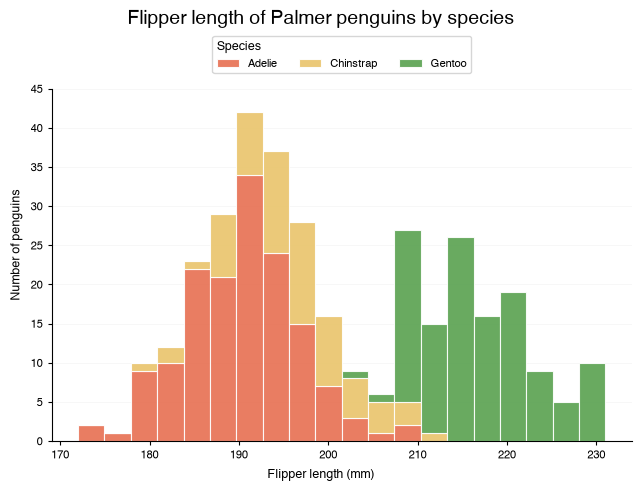

In [17]:
from datachart.constants import LEGEND_LOCATION

Histogram(
    data=penguins_by_species,
    subtitle=SPECIES,
    style=[{"plot_hist_color": "#e76f51"}, {"plot_hist_color": "#e9c46a"}, None],
    title="Flipper length of Palmer penguins by species",
    xlabel="Flipper length (mm)",
    ylabel="Number of penguins",
    xticks=FLIPPER_TICKS,
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
    # a titled, one-row legend above the axes
    legend={"title": "Species", "location": LEGEND_LOCATION.OUTSIDE_TOP, "ncols": 3},
).show()

### Subplots

Overlaid series get hard to read once their shapes cross. `subplots=True` draws each series in its own panel: `subtitle` titles the panels, `title`, `xlabel` and `ylabel` stay global, and `max_cols` limits the panels per row. On their own, the panels bin and scale independently, so a bar in one panel does not compare with a bar in the next. `sharex=True` puts the panels on one value axis with shared bins, so the species line up bin for bin, and `sharey=True` puts them on one count axis, so the smaller Chinstrap sample (68 penguins against 151 Adelie) no longer fills its panel.

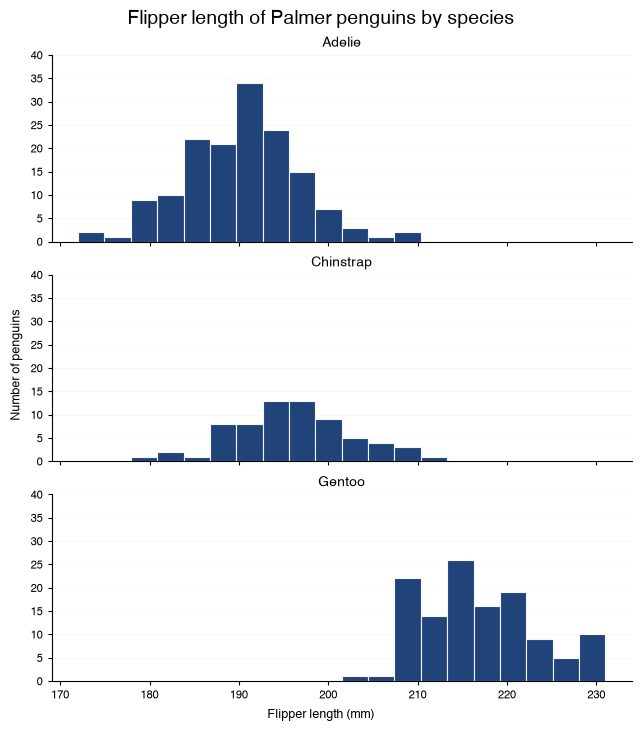

In [18]:
Histogram(
    data=penguins_by_species,
    subtitle=SPECIES,
    title="Flipper length of Palmer penguins by species",
    xlabel="Flipper length (mm)",
    ylabel="Number of penguins",
    xticks=FLIPPER_TICKS,
    figsize=FIG_SIZE.FULL_TALL,
    show_grid=SHOW_GRID.Y,
    # one panel per species, stacked in a column
    subplots=True,
    max_cols=1,
    # one set of bins and one count axis for all panels
    sharex=True,
    sharey=True,
).show()

## Additional Features

### Density view

Counts depend on the sample size: in the panels above the Chinstrap histogram is small because fewer Chinstrap penguins were measured, not because their flippers are unusual. `show_density=True` rescales the bars so that the total area of each series is 1, which makes samples of different sizes comparable. Per density, the Adelie and Chinstrap distributions have about the same height and width, with the Chinstrap one shifted about 6 mm to the right.

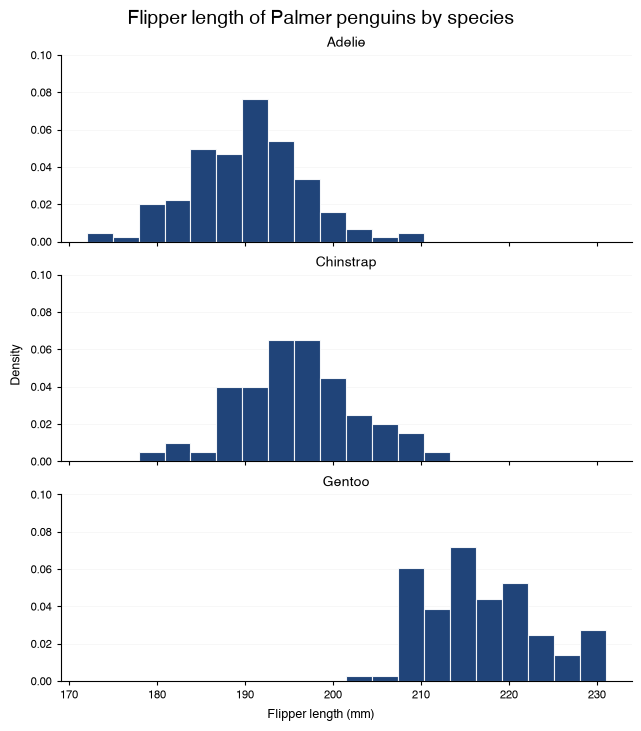

In [19]:
Histogram(
    data=penguins_by_species,
    subtitle=SPECIES,
    title="Flipper length of Palmer penguins by species",
    xlabel="Flipper length (mm)",
    ylabel="Density",
    xticks=FLIPPER_TICKS,
    figsize=FIG_SIZE.FULL_TALL,
    show_grid=SHOW_GRID.Y,
    subplots=True,
    max_cols=1,
    sharex=True,
    sharey=True,
    # the density instead of the count
    show_density=True,
).show()

### Density curve

A histogram's shape depends on where its bin edges fall; a kernel density estimate smooths the same values into a curve that does not. [datachart.utils.stats.kde1d](../../../references/utils/stats/#datachart.utils.stats.kde1d) computes the curve and returns `{x, y}` points that a [LineChart](../../../references/charts/linechart/#datachart.charts.LineChart) draws, and [Panel](../../utility/panel/) lays the curve over a density histogram; both integrate to 1, so they share the y-axis. The `bandwidth` argument of `kde1d` sets how smooth the curve is: a [BANDWIDTH](../../../references/constants/#datachart.constants.BANDWIDTH) rule (Scott's by default) or a number, where smaller values follow the data more closely. The [Statistics](../../utility/stats/) guide covers the estimate in more depth.

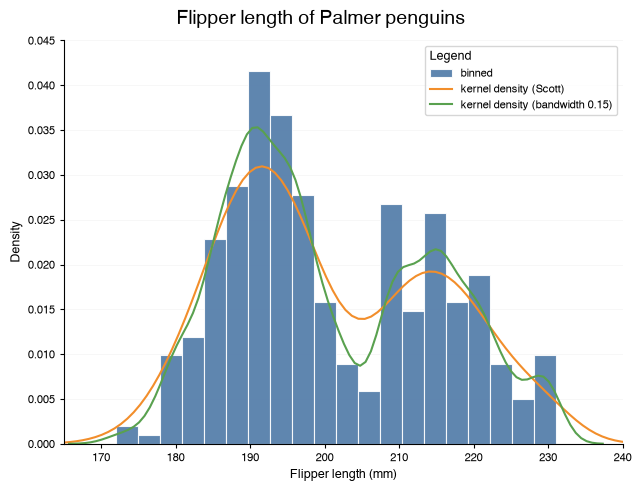

In [20]:
from datachart.charts import LineChart
from datachart.utils import Panel
from datachart.utils.stats import kde1d

# the default bandwidth and a narrower one
smooth = kde1d(flippers)
detailed = kde1d(flippers, bandwidth=0.15)

Panel(
    [
        Histogram(data=penguins, subtitle="binned", show_density=True),
        LineChart(data=smooth, subtitle="kernel density (Scott)"),
        LineChart(data=detailed, subtitle="kernel density (bandwidth 0.15)"),
    ],
    title="Flipper length of Palmer penguins",
    xlabel="Flipper length (mm)",
    ylabel_left="Density",
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
    # the curves run past the data, so the range is fixed
    xmin=165,
    xmax=240,
).show()

### Cumulative view

Some questions are about thresholds, not shapes: *how many penguins have flippers of 200 mm or less?* `show_cumulative=True` makes each bar hold the count of all values up to and including its bin, so the bars climb to the sample size. Combined with `show_density=True`, the bars hold the share of values instead and every series climbs to 1, which is the empirical cumulative distribution. At 200 mm, 95% of the Adelie penguins and 74% of the Chinstrap penguins are counted, and not a single Gentoo penguin.

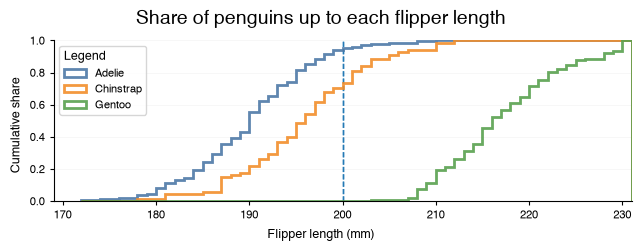

In [21]:
Histogram(
    data=penguins_by_species,
    subtitle=SPECIES,
    style={"plot_hist_type": HISTOGRAM_TYPE.STEP, "plot_hist_edge_width": 2},
    bar_mode=BAR_MODE.OVERLAY,
    # the 200 mm threshold
    vlines={"x": 200, "style": {"plot_vline_style": LINE_STYLE.DASHED}},
    title="Share of penguins up to each flipper length",
    xlabel="Flipper length (mm)",
    ylabel="Cumulative share",
    xticks=FLIPPER_TICKS,
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
    legend={"location": LEGEND_LOCATION.UPPER_LEFT},
    num_bins=59,
    xmax=231,
    # the running share of each species
    show_cumulative=True,
    show_density=True,
).show()

### Axis scales

On a linear count axis the bins in the tail of a distribution hold a handful of values and vanish next to the peak. `scaley` (or `scalex` for a horizontal histogram) takes a [SCALE](../../../references/constants/#datachart.constants.SCALE) member, and a logarithmic count axis gives every occupied bin a visible bar. The bins stay equal-width on the data scale whichever axis scale is applied, so a log scale on the binned axis stretches them unevenly and is rarely what you want.

Flipper lengths have no long tail, so this example switches dataset. `quakes`, defined in a hidden cell, holds 5,000 illustrative earthquake magnitudes from a seeded generator that follows the Gutenberg-Richter law: every step of one magnitude up makes earthquakes about ten times rarer. On a linear axis the strong earthquakes are invisible; on a log axis the counts fall along a straight line, which is how seismologists read the law.

In [22]:
import numpy as np

# illustrative magnitudes above 2.5, Gutenberg-Richter with b = 1
rng = np.random.RandomState(42)
quakes = [{"x": float(m)} for m in 2.5 + rng.exponential(1 / np.log(10), 5_000)]

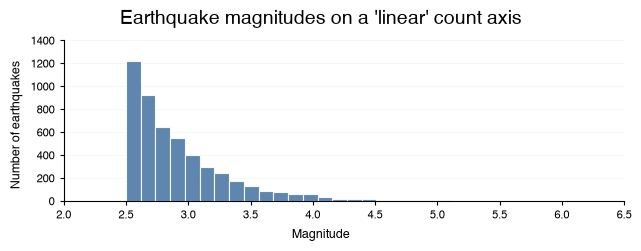

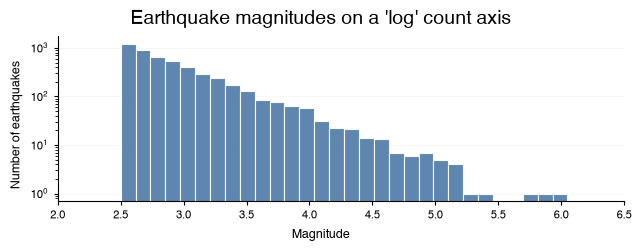

In [23]:
from datachart.constants import SCALE

for scale in [SCALE.LINEAR, SCALE.LOG]:
    Histogram(
        data=quakes,
        title=f"Earthquake magnitudes on a '{scale}' count axis",
        xlabel="Magnitude",
        ylabel="Number of earthquakes",
        figsize=FIG_SIZE.FULL_SHORT,
        show_grid=SHOW_GRID.Y,
        num_bins=30,
        # the scale of the count axis
        scaley=scale,
    ).show()

### Custom data keys

Data from a file or an API rarely calls its column `x`, and renaming every record just to plot it is a chore. The `x` argument names the key that holds the value to bin (a list of keys for several series). `penguin_records` stores the penguins the way the published dataset names its columns, so the same records can be binned by body mass instead of flipper length:

In [24]:
penguin_records = [
    {"species": species, "flipper_length_mm": flipper, "body_mass_g": mass}
    for species in SPECIES
    for flipper, mass in PENGUINS[species]
]
penguin_records[:2]

[{'species': 'Adelie', 'flipper_length_mm': 181, 'body_mass_g': 3750},
 {'species': 'Adelie', 'flipper_length_mm': 186, 'body_mass_g': 3800}]

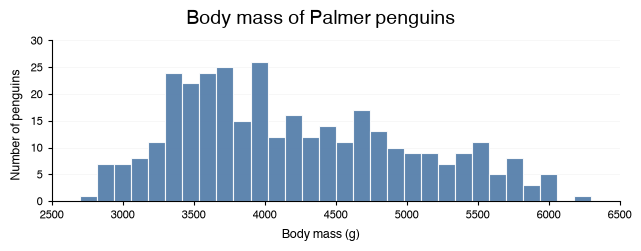

In [25]:
Histogram(
    data=penguin_records,
    # the key that holds the value to bin
    x="body_mass_g",
    title="Body mass of Palmer penguins",
    xlabel="Body mass (g)",
    ylabel="Number of penguins",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    num_bins=30,
).show()

## Real-World Examples

The examples below put the features above to work, each one answering a question. The data lives in hidden cells; each example says what its data is and where it comes from.

### Example 1: Do Marathoners Race the Clock? (Fine Bins, Hour Ticks, and Reference Lines)

A study of millions of marathon results found that finish times bunch up just before round-number goals such as four hours, as runners push to beat them (Allen, Dechow, Pope and Wu, *Management Science*, 2017). `finish_times` holds 20,000 illustrative finish times in minutes from a seeded generator that reproduces the effect: a broad spread of times, where some runners heading for just over 3:00, 3:30, 4:00, 4:30 or 5:00 are pulled in under the mark, most strongly at the full hours. With the default 20 bins each bin is 12 minutes wide and the bunching disappears into a smooth hump, so the example uses one-minute bins. `xticks` and `xticklabels` print the axis in hours and minutes, and `vlines` mark the goals, so each spike can be seen to sit just left of its line.

In [26]:
rng = np.random.RandomState(42)
# illustrative finish times in minutes, 2:30 to 6:30
times = rng.gamma(shape=30, scale=8.2, size=20_000) + 25
times = times[(times >= 150) & (times < 390)]
GOALS = [180, 210, 240, 270, 300]
# some runners heading for just over a goal push to finish just under it
for goal in GOALS:
    share = 0.45 if goal % 60 == 0 else 0.2
    pushed = (times >= goal) & (times < goal + 6) & (rng.random_sample(len(times)) < share)
    times[pushed] = goal - rng.uniform(0, 2, pushed.sum())
finish_times = [{"x": float(minutes)} for minutes in times]
HOUR_TICKS = list(range(150, 391, 30))
HOUR_LABELS = [f"{m // 60}:{m % 60:02d}" for m in HOUR_TICKS]

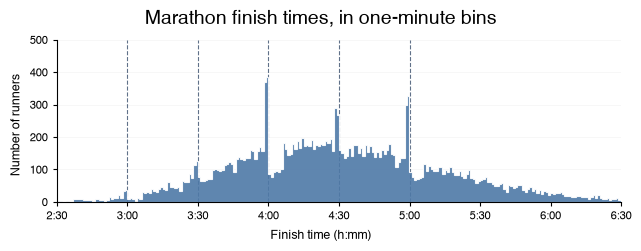

In [27]:
Histogram(
    data=finish_times,
    style={"plot_hist_type": HISTOGRAM_TYPE.STEP_FILLED},
    # the round-number goals
    vlines=[
        {
            "x": goal,
            "style": {"plot_vline_color": "#1d3557", "plot_vline_style": LINE_STYLE.DASHED, "plot_vline_width": 0.8},
        }
        for goal in GOALS
    ],
    title="Marathon finish times, in one-minute bins",
    xlabel="Finish time (h:mm)",
    ylabel="Number of runners",
    # the axis in hours and minutes
    xticks=HOUR_TICKS,
    xticklabels=HOUR_LABELS,
    xmin=150,
    xmax=390,
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    # one bin per minute
    num_bins=240,
).show()

### Example 2: Did the New Onboarding Lengthen Sessions? (Emphasis, Density View, and Medians)

`session_durations` holds illustrative session durations, in minutes, from an A/B test of a redesigned onboarding flow: 5,000 sessions of the control group and 600 of the new variant, drawn from seeded log-normal generators. The groups differ eightfold in size, so `show_density` compares their shapes rather than their counts. `emphasis` mutes the control group into a reference and highlights the variant, which also overlays the two instead of stacking them, and `vlines` mark each group's median, the robust summary for a right-skewed duration.

In [28]:
rng = np.random.RandomState(11)
control = rng.lognormal(mean=1.6, sigma=0.5, size=5_000)
variant = rng.lognormal(mean=1.9, sigma=0.5, size=600)
session_durations = [
    [{"x": float(minutes)} for minutes in control],
    [{"x": float(minutes)} for minutes in variant],
]
MEDIANS = {"control": float(np.median(control)), "variant": float(np.median(variant))}

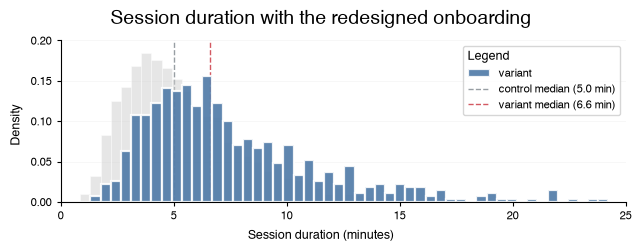

In [29]:
Histogram(
    data=session_durations,
    subtitle=["control", "variant"],
    # the control group is the reference, the variant the question
    emphasis=["background", "highlight"],
    # each group's median
    vlines=[
        {
            "x": median,
            "label": f"{group} median ({median:.1f} min)",
            "style": {"plot_vline_color": color, "plot_vline_style": LINE_STYLE.DASHED},
        }
        for (group, median), color in zip(MEDIANS.items(), ["#6c757d", "#c1121f"])
    ],
    title="Session duration with the redesigned onboarding",
    xlabel="Session duration (minutes)",
    ylabel="Density",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    num_bins=60,
    xmin=0,
    xmax=25,
    # compare the shapes, not the sample sizes
    show_density=True,
    show_legend=True,
).show()

### Example 3: Did the Release Fatten the Latency Tail? (Log Counts, the Cumulative View, and a Grid)

`latency` holds the response times, in milliseconds, of 20,000 illustrative requests to a web service in the week before and the week after a release, from seeded log-normal generators; after the release, about 3% of requests take a slow path. The service promises that 99% of requests answer within 200 ms. The typical request did not change, so the peaks overlap, and the question lives in the tail. The left chart overlays both weeks as outlines on a log count axis, where the new bump of slow requests shows up. The right chart shows the cumulative share of requests, zoomed to the top 10% with `ymin`, with the 99% promise as a horizontal line and the 200 ms limit as a vertical one: before the release the curve reaches 99% left of the limit, after it only to the right. [Grid](../../utility/grid/) puts the two views side by side.

In [30]:
rng = np.random.RandomState(7)
before = rng.lognormal(mean=3.7, sigma=0.45, size=20_000)
slow = rng.random_sample(20_000) < 0.03
after = np.where(
    slow,
    rng.lognormal(mean=5.6, sigma=0.35, size=20_000),
    rng.lognormal(mean=3.7, sigma=0.45, size=20_000),
)
latency = [
    [{"x": float(ms)} for ms in before if ms < 800],
    [{"x": float(ms)} for ms in after if ms < 800],
]
WEEKS = ["week before", "week after"]
WEEK_STYLE = [
    {"plot_hist_type": "step", "plot_hist_edge_color": "#6c757d", "plot_hist_edge_width": 1.5},
    {"plot_hist_type": "step", "plot_hist_edge_color": "#c1121f", "plot_hist_edge_width": 1.5},
]

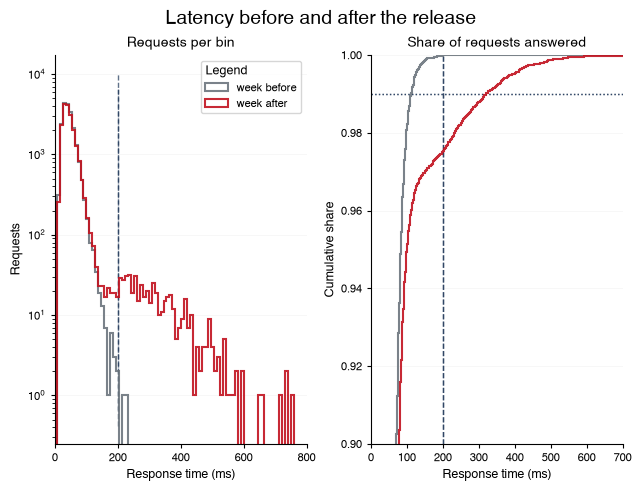

In [31]:
from datachart.utils import Grid

LIMIT = {"x": 200, "style": {"plot_vline_color": "#1d3557", "plot_vline_style": LINE_STYLE.DASHED}}

counts = Histogram(
    data=latency,
    subtitle=WEEKS,
    style=WEEK_STYLE,
    bar_mode=BAR_MODE.OVERLAY,
    vlines=LIMIT,
    title="Requests per bin",
    xlabel="Response time (ms)",
    ylabel="Requests",
    show_grid=SHOW_GRID.Y,
    num_bins=80,
    # the tail shows on a log count axis
    scaley=SCALE.LOG,
    show_legend=True,
)

cumulative = Histogram(
    data=latency,
    subtitle=WEEKS,
    style=WEEK_STYLE,
    bar_mode=BAR_MODE.OVERLAY,
    vlines=LIMIT,
    # the 99% promise
    hlines={"y": 0.99, "style": {"plot_hline_color": "#1d3557", "plot_hline_style": LINE_STYLE.DOTTED}},
    title="Share of requests answered",
    xlabel="Response time (ms)",
    ylabel="Cumulative share",
    show_grid=SHOW_GRID.Y,
    num_bins=400,
    show_cumulative=True,
    show_density=True,
    # zoom into the top 10%, and past the slowest requests
    xmax=700,
    ymin=0.9,
    ymax=1.0,
)

Grid(
    [[counts, cumulative]],
    title="Latency before and after the release",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()